/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

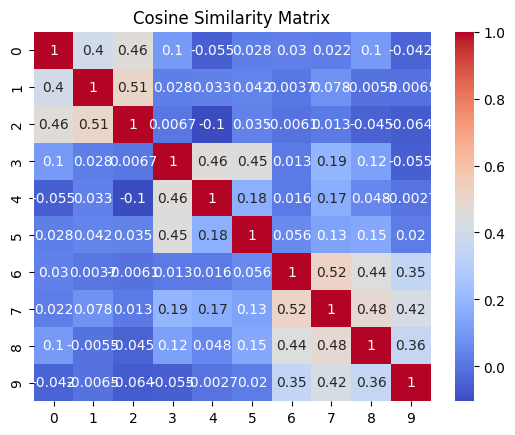

Top 2 similar sentences:
The bowler took a wicket in the last over.  | Score: 0.8502183
Cricket is played between two teams.  | Score: 0.48888198


In [1]:
# Install library
!pip install sentence-transformers seaborn matplotlib

# Import
from sentence_transformers import SentenceTransformer
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 10 sentences (Cricket, Cooking, Cybersecurity)
sentences = [
    "Virat Kohli is one of the best batsmen in cricket.",
    "The bowler took a wicket in the last over.",
    "Cricket is played between two teams.",

    "Cooking requires patience and good ingredients.",
    "Boiling water is the first step in making pasta.",
    "Spices enhance the flavor of food.",

    "Cybersecurity protects systems from attacks.",
    "Hackers try to exploit vulnerabilities.",
    "Strong passwords improve security.",

    "Data breaches can cause serious damage."
]

# Load model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings
embeddings = model.encode(sentences)

# Cosine similarity matrix
similarity_matrix = np.inner(embeddings, embeddings)

# Plot heatmap
sns.heatmap(similarity_matrix, annot=True, cmap="coolwarm")
plt.title("Cosine Similarity Matrix")
plt.show()

# Query sentence
query = "The bowler took three wickets in one over"
query_embedding = model.encode([query])

# Similarity with all sentences
scores = np.inner(query_embedding, embeddings)[0]

# Top 2 similar
top_indices = scores.argsort()[-2:][::-1]

print("Top 2 similar sentences:")
for i in top_indices:
    print(sentences[i], " | Score:", scores[i])